# Convolutional Neural Networks (CNN) & Feature Maps

This notebook demonstrates the PyTorch CNN baseline used in the application to compare against the NumPy model.

## Learning Objectives
- Understand CNN architecture (Conv2D, MaxPool, Channels).
- Visualize how a CNN "sees" an image using Feature Maps.

In [1]:
import sys
import pathlib

# Dynamically resolve project root
PROJECT_ROOT = pathlib.Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
print(f"Project root added to path: {PROJECT_ROOT}")

Project root added to path: D:\project\DIGIT Recognition


## Architecture Overview

Unlike Dense layers that flatten the image instantly (losing spatial structure), CNNs apply 2D sliding windows (kernels) to extract spatial features like edges, curves, and corners.

    1x28x28 Image
       ↓
    Conv2D (8 channels, 3x3 kernel) -> ReLU -> MaxPool (2x2)
       ↓
    Conv2D (16 channels, 3x3 kernel) -> ReLU -> MaxPool (2x2)
       ↓
    Flatten (16 * 7 * 7 = 784)
       ↓
    Linear (784 -> 10)

In [2]:
import torch
import matplotlib.pyplot as plt
from backend.app.model.cnn import SimpleCNN
from backend.app.dataset.mnist_loader import load_mnist

# Load model
model = SimpleCNN()
weights_path = PROJECT_ROOT / "backend" / "weights" / "cnn_model.pt"
model.load_state_dict(torch.load(weights_path, weights_only=True))
model.eval()

# Load a test image (NOT flat, keep 28x28 spatial shape)
images, labels = load_mnist(split="test", subset_size=1, flat=False)
tensor_img = torch.tensor(images[0:1]).unsqueeze(1) # shape (1, 1, 28, 28)

print(f"Input Tensor Shape: {tensor_img.shape}")

Input Tensor Shape: torch.Size([1, 1, 28, 28])


## Visualizing Feature Maps

Let's extract the intermediate activations from `Conv1` and `Conv2`.

In [3]:
with torch.no_grad():
    logits, intermediates = model(tensor_img, return_intermediates=True)

conv1_features = intermediates["conv1_activation"] # Shape: (1, 8, 28, 28)
conv2_features = intermediates["conv2_activation"] # Shape: (1, 16, 14, 14)

print(f"Conv1 Features Shape: {conv1_features.shape}")
print(f"Conv2 Features Shape: {conv2_features.shape}")

Conv1 Features Shape: (1, 8, 28, 28)
Conv2 Features Shape: (1, 16, 14, 14)


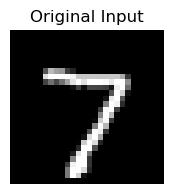

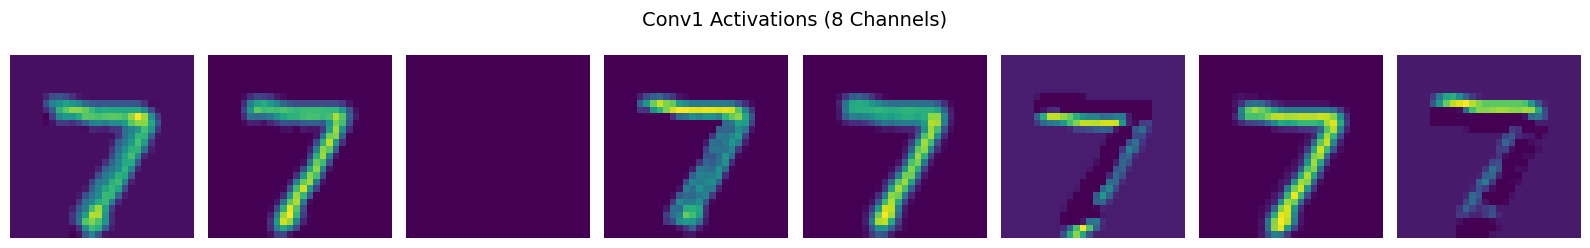

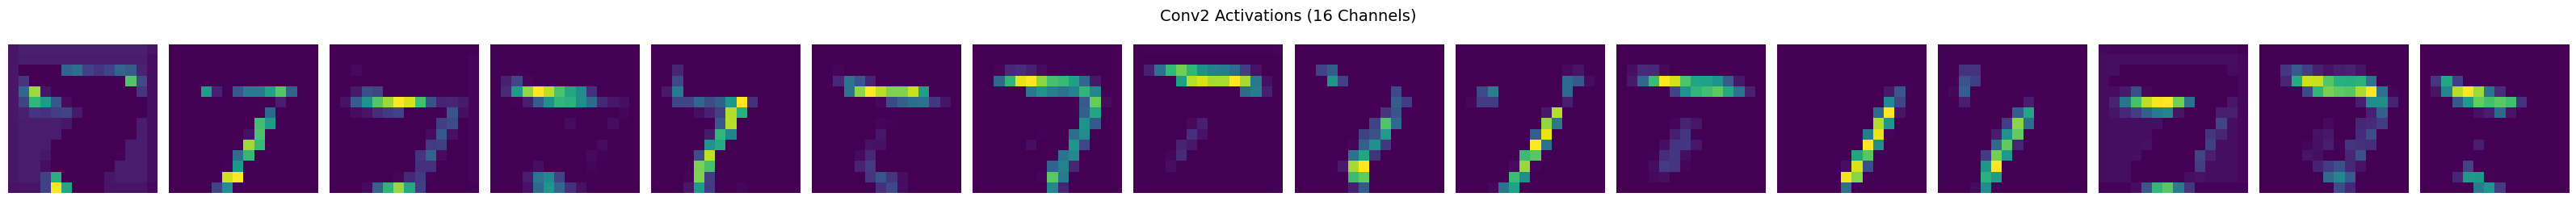

In [4]:
def plot_features(features, title):
    channels = features.shape[1]
    fig, axes = plt.subplots(1, channels, figsize=(channels * 2, 2.5))
    fig.suptitle(title, fontsize=14)
    for i in range(channels):
        axes[i].imshow(features[0, i], cmap='viridis')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Show the original image
plt.figure(figsize=(2,2))
plt.title("Original Input")
plt.imshow(images[0], cmap='gray')
plt.axis('off')
plt.show()

# Show feature maps
plot_features(conv1_features, "Conv1 Activations (8 Channels)")
plot_features(conv2_features, "Conv2 Activations (16 Channels)")

## Key Takeaways
- Early layers (`Conv1`) learn simple textures and edges.
- Deeper layers (`Conv2`, operating on pooled data) recognize complex abstract shapes.
- Max Pooling drastically reduces memory footprint while creating translation invariance (making the model robust to small shifts).

## Interview Questions
- **What is a Feature Map?** The output activation resulting from applying a convolutional filter across the input image. It represents where a specific feature (like a vertical edge) was detected.
- **Why use Pooling?** Pooling reduces spatial dimensions, cutting down the number of parameters and computation, while helping the network become invariant to small translations in the image.
- **Why are CNNs better for images than Fully Connected Networks?** CNNs preserve the 2D spatial relationships of pixels and share weights (kernels) across the entire image, making them vastly more efficient and spatially aware.